In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Görselleştirmelerin notebook içinde görünmesi için
%matplotlib inline

# Veriyi yükle
df = pd.read_csv('musteri_kayip.csv')

# İlk 5 satıra göz atalım
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Veri setinin özet bilgisi
print("Veri Seti Şekli:", df.shape)
df.info()

# Sayısal sütunların istatistiksel özeti
df.describe()

Veri Seti Şekli: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [3]:
# Sadece boşluk karakteri içeren satırları filtreleyelim
gizli_eksik = df[df['TotalCharges'] == " "]
print(f"Sadece boşluk içeren satır sayısı: {len(gizli_eksik)}")

# Bu satırlara bir göz atalım (Genelde tenure yani abonelik süresi 0 olanlardır)
gizli_eksik[['tenure', 'MonthlyCharges', 'TotalCharges']].head()

Sadece boşluk içeren satır sayısı: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,


In [5]:
# 1. Adım: Sadece boşluk (" ") içeren satırları bulalım
bosluklar = df[df['TotalCharges'] == " "]
print(f"Sadece boşluk karakteri içeren satır sayısı: {len(bosluklar)}")

# 2. Adım: Bu boşlukları NaN (Not a Number) yap ve sütunu float'a çevir
# errors='coerce' parametresi, sayıya çevrilemeyen her şeyi (boşluk dahil) NaN yapar.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Adım: Şimdi gerçekten kaç tane 'null' (boş) verimiz oldu bakalım
print("Gerçek eksik veri sayısı:", df['TotalCharges'].isnull().sum())

# 4. Adım: Bu boşlukları 0 ile dolduralım (genelde yeni müşteriler oldukları için)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Sonuç kontrol
print("Sütun tipi artık:", df['TotalCharges'].dtype)

Sadece boşluk karakteri içeren satır sayısı: 11
Gerçek eksik veri sayısı: 11
Sütun tipi artık: float64


In [6]:
# Sinsi boşlukları NaN yap ve 0 ile doldur
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Son bir kontrol: Eksik veri kaldı mı?
print(f"Toplam Eksik Veri: {df.isnull().sum().sum()}")
# Veri tipini doğrula
print(f"TotalCharges Tipi: {df['TotalCharges'].dtype}")

Toplam Eksik Veri: 0
TotalCharges Tipi: float64


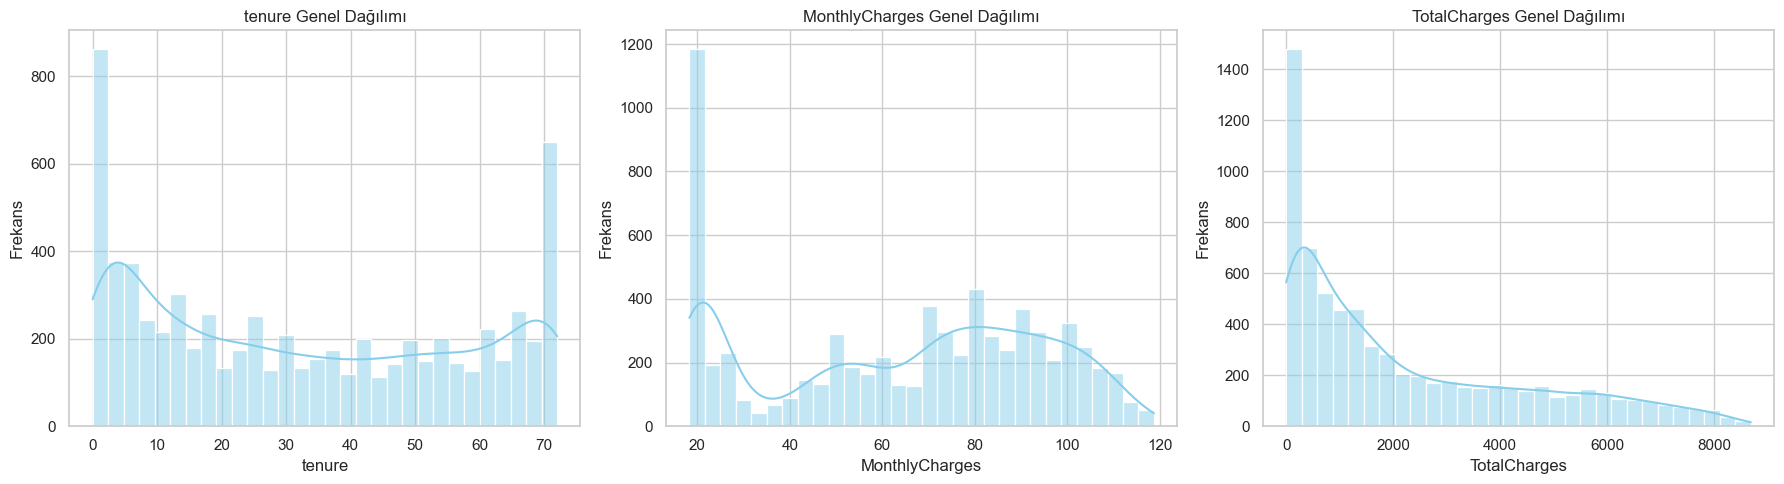

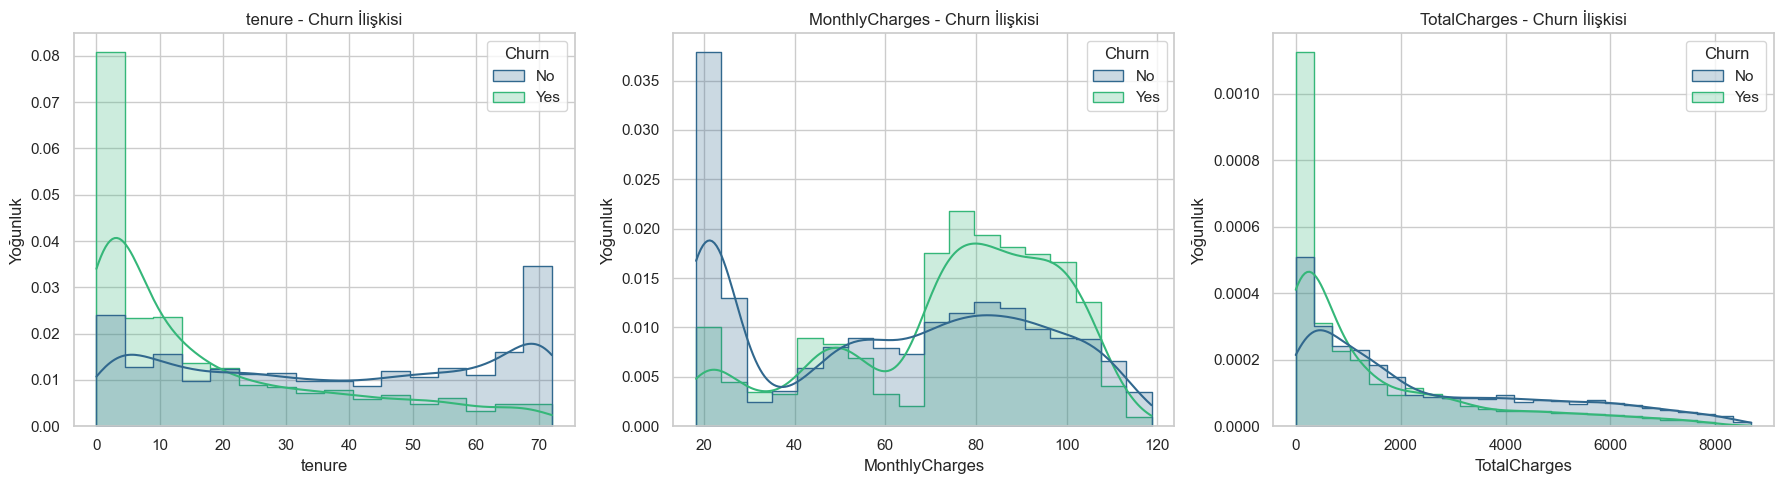

In [7]:
# Görselleştirme stilini ayarlayalım
sns.set(style="whitegrid")

# Analiz edilecek sayısal sütunlar
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 1. TEKLİ DEĞİŞKEN ANALİZİ: Genel Dağılım (Histogram)
# Bu kısım, verinin genel yapısını (sola mı yatık, sağa mı, ortada mı toplanmış) gösterir.
plt.figure(figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Genel Dağılımı')
    plt.xlabel(col)
    plt.ylabel('Frekans')

plt.tight_layout()
plt.show()

# 2. ÇOKLU DEĞİŞKEN ANALİZİ: Churn'e Göre Dağılım (Histogram + KDE)
# Bu kısım, ayrılan (Yes) ve kalan (No) müşterilerin farkını ortaya koyar.
plt.figure(figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    # hue='Churn' parametresi, veriyi Churn durumuna göre renklendirir
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element="step", stat="density", common_norm=False, palette='viridis')
    plt.title(f'{col} - Churn İlişkisi')
    plt.xlabel(col)
    plt.ylabel('Yoğunluk')

plt.tight_layout()
plt.show()

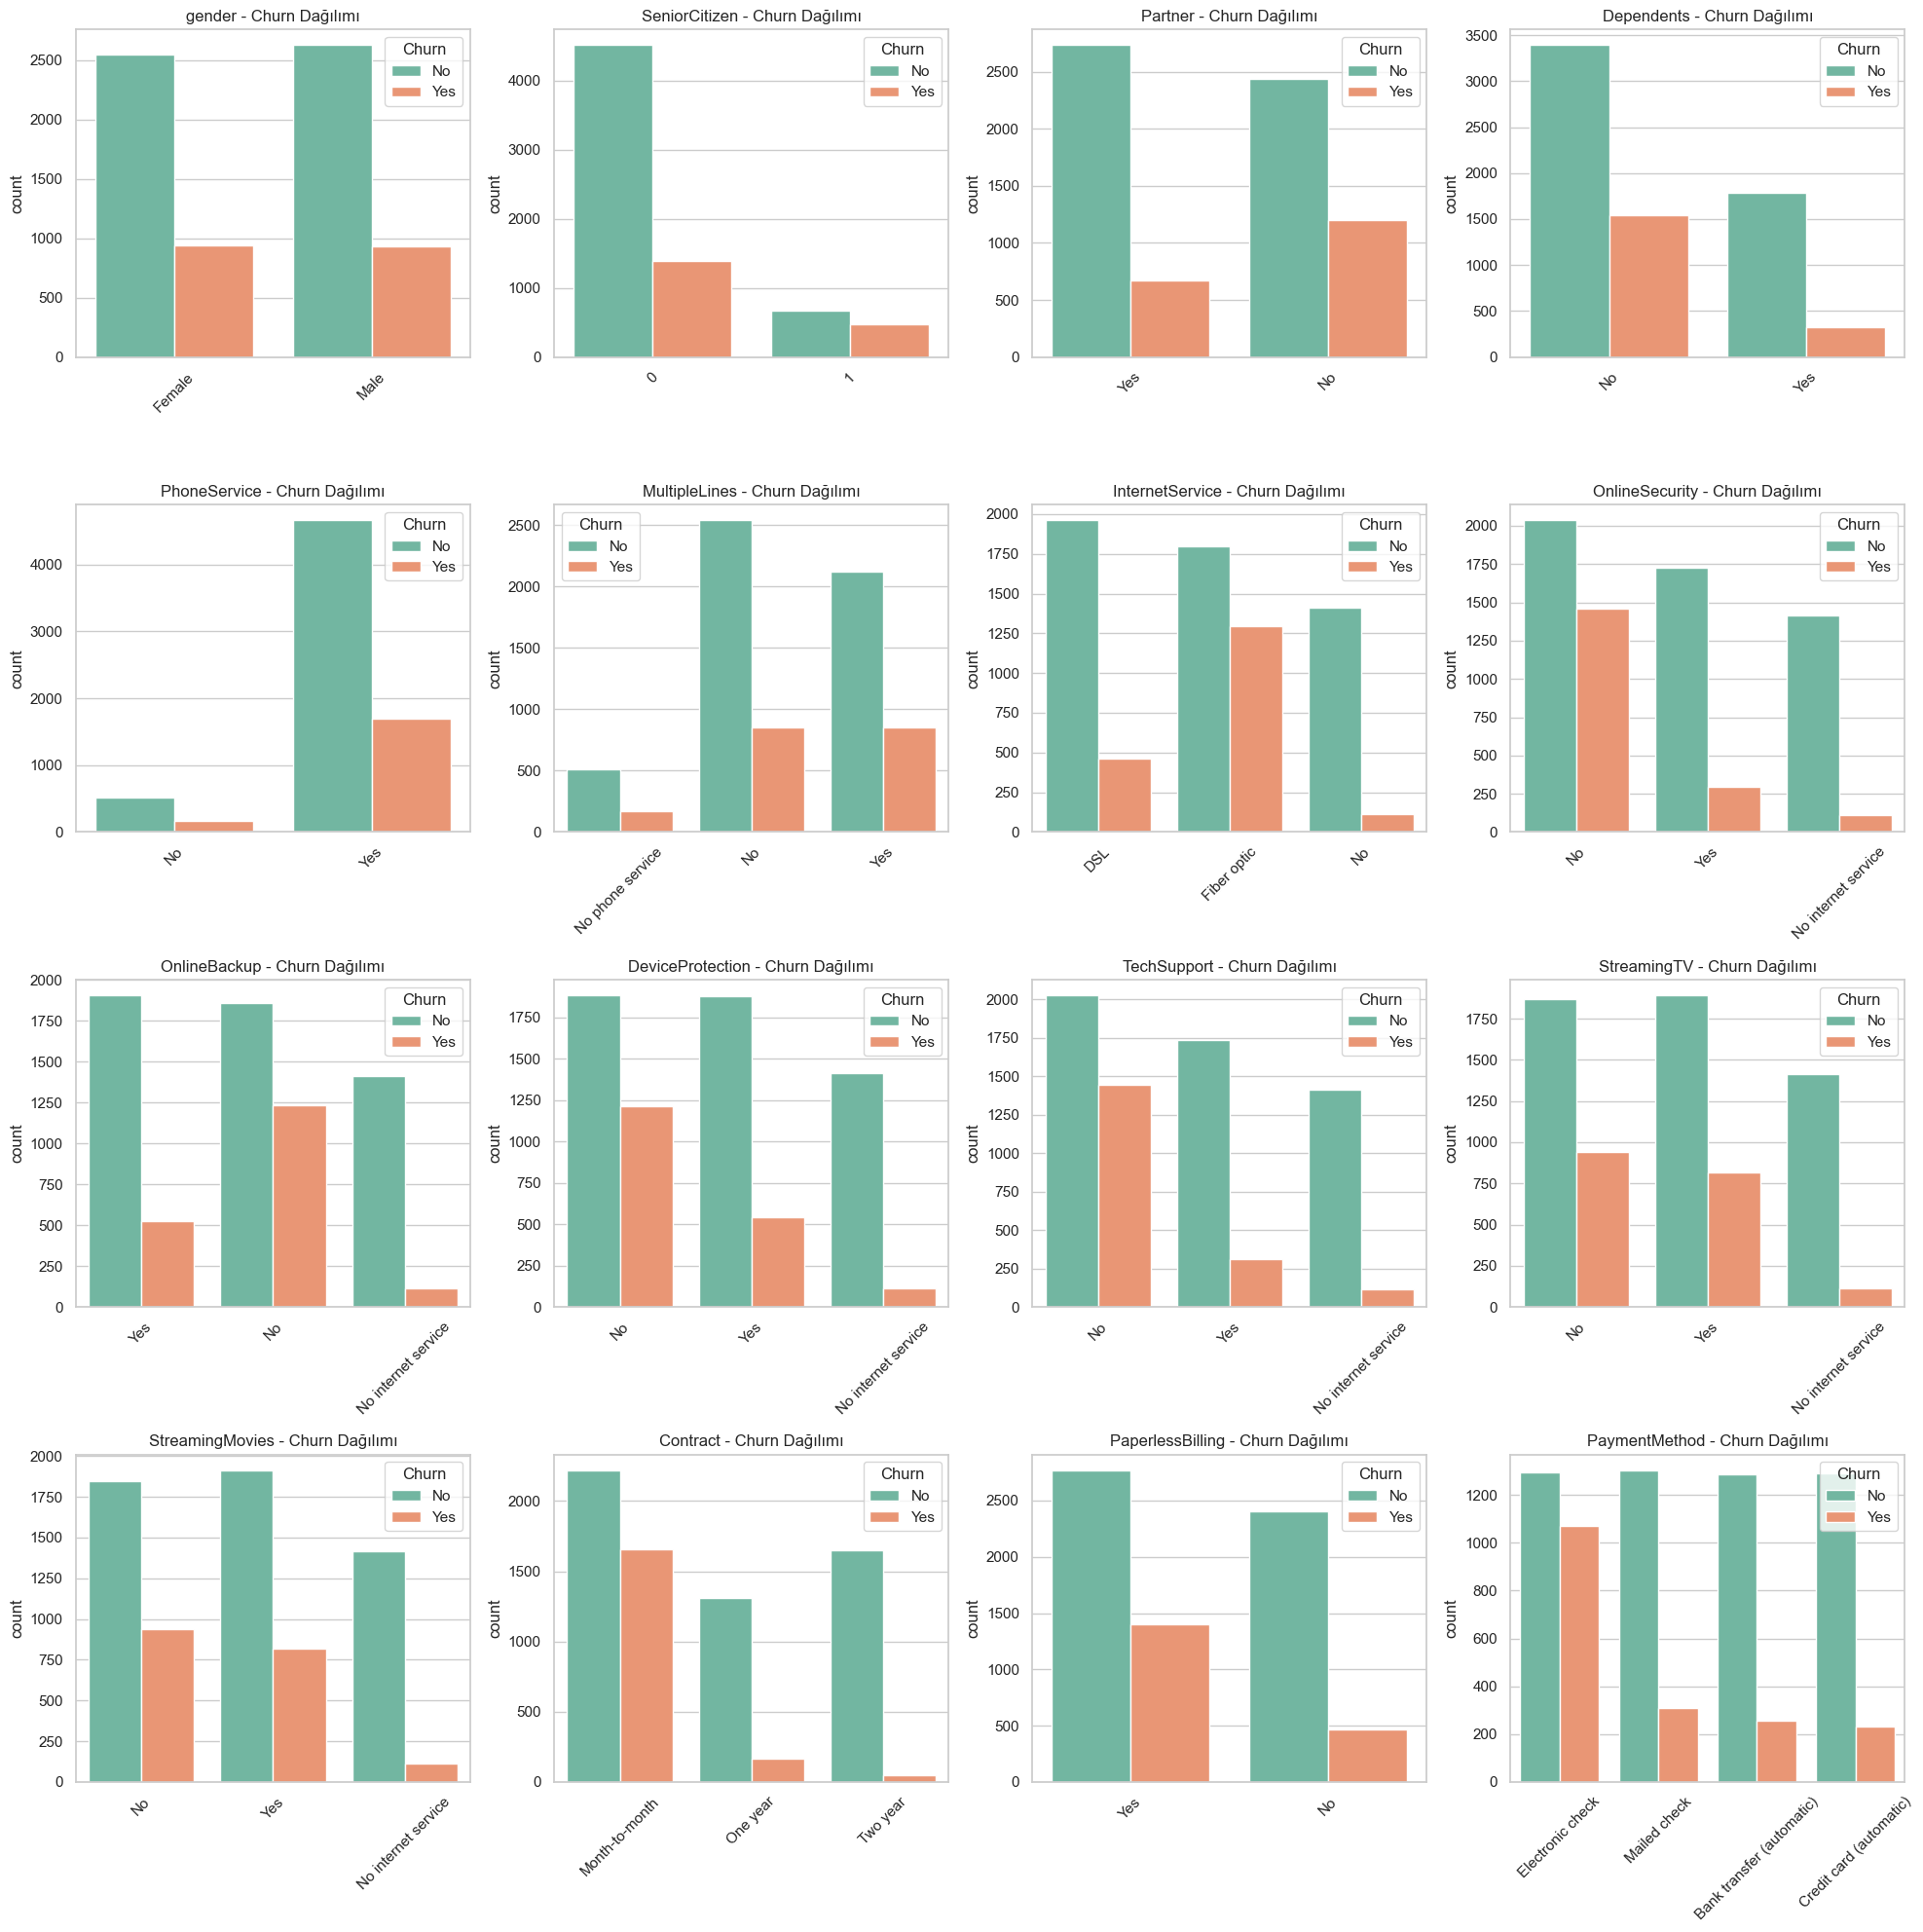

In [8]:
# Görselleştirme stilini ayarlayalım
sns.set(style="whitegrid")

# Analiz edilecek ana kategorik değişkenler
# Bu değişkenler müşterinin profilini ve satın aldığı hizmetleri gösterir
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# Çok sayıda grafik olacağı için döngü ile çizdirmek en temiz yoldur.
# 4 satır ve 4 sütunluk bir tablo (grid) oluşturalım
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten() # Eksenleri tek boyutlu listeye çevirir (döngü kolaylığı için)

for i, col in enumerate(cat_cols):
    # hue='Churn' parametresi ile ayrılan ve kalanları renklerle ayırıyoruz
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='Set2')
    
    # Başlık ve eksen ayarları
    axes[i].set_title(f'{col} - Churn Dağılımı')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45) # Yazıların üst üste binmemesi için eğik yaz

# Düzenin sıkışık olmaması için
plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder 

# 1. VERİYİ YÜKLEME VE TEMİZLEME (Hata almamak için baştan alıyoruz)
df = pd.read_csv('musteri_kayip.csv')

# TotalCharges temizliği
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# customerID gereksiz
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. ENCODING (KATEGORİK -> SAYISAL)

# A) Binary (İki seçenekli) Değişkenler için Label Encoding
le = LabelEncoder()
binary_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() == 2]

print("Label Encoding Yapılan Sütunlar:\n", binary_cols)

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# B) Multi-Class (Çok seçenekli) Değişkenler için One-Hot Encoding
# drop_first=True diyerek gereksiz kolon tekrarından kaçınıyoruz
df = pd.get_dummies(df, drop_first=True)

# 3. SCALING (ÖLÇEKLENDİRME)
# Verilerimiz normal dağılmadığı için MinMaxScaler kullanıyoruz
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# SONUÇLARI GÖRELİM
print("\n--- İşlenmiş Veri Seti Boyutu ---")
print(df.shape)
print("\n--- İlk 5 Satır ---")
print(df.head())

Label Encoding Yapılan Sütunlar:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

--- İşlenmiş Veri Seti Boyutu ---
(7043, 31)

--- İlk 5 Satır ---
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        1           0  0.013889             0   
1       1              0        0           0  0.472222             1   
2       1              0        0           0  0.027778             1   
3       1              0        0           0  0.625000             0   
4       0              0        0           0  0.027778             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1        0.115423      0.003437      0  ...   
1                 0        0.385075      0.217564      0  ...   
2                 1        0.354229      0.012453      1  ...   
3                 0        0.239303      0.211951      0  ...   
4                 1        0.521891      0.017462     

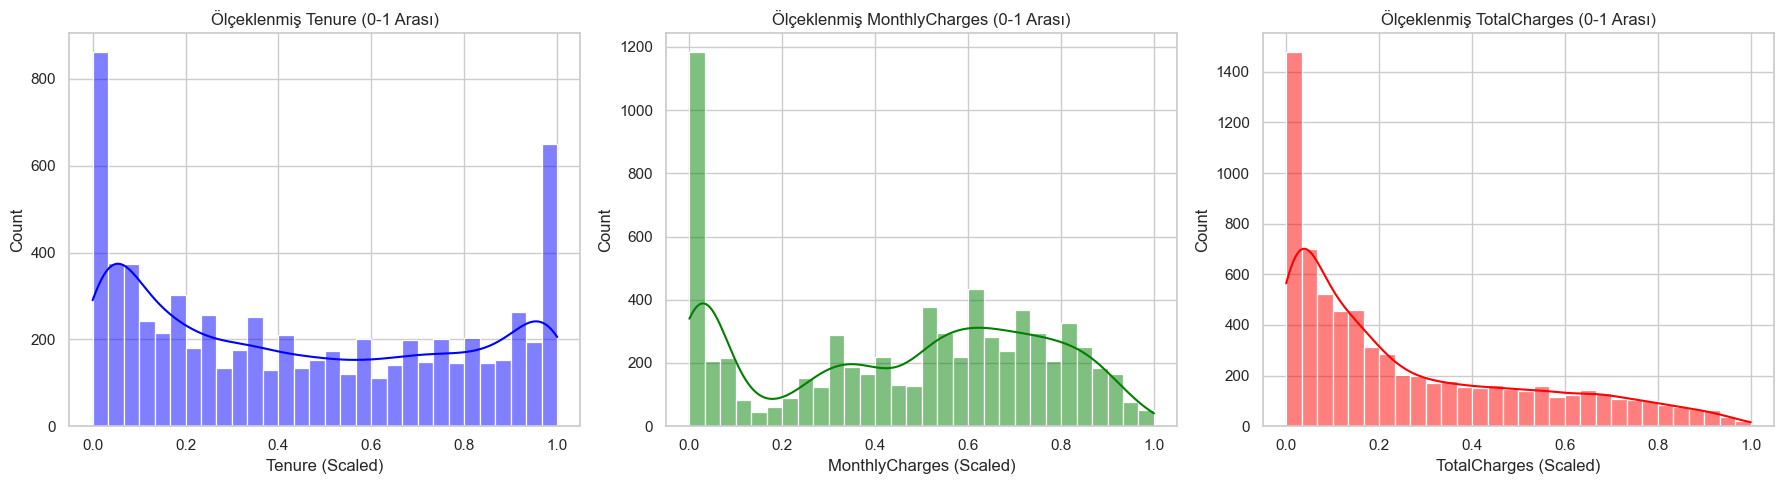

In [12]:
# Daha önce oluşturduğumuz ölçeklenmiş 'df' veri setini kullanıyoruz.
# (Eğer df kaybolduysa yukarıdaki kod bloğunu tekrar çalıştırmalısın)

plt.figure(figsize=(18, 5))

# 1. Ölçeklenmiş Tenure (Abonelik Süresi)
plt.subplot(1, 3, 1)
sns.histplot(df['tenure'], kde=True, color='blue', bins=30)
plt.title('Ölçeklenmiş Tenure (0-1 Arası)')
plt.xlabel('Tenure (Scaled)')

# 2. Ölçeklenmiş MonthlyCharges (Aylık Ücret)
plt.subplot(1, 3, 2)
sns.histplot(df['MonthlyCharges'], kde=True, color='green', bins=30)
plt.title('Ölçeklenmiş MonthlyCharges (0-1 Arası)')
plt.xlabel('MonthlyCharges (Scaled)')

# 3. Ölçeklenmiş TotalCharges (Toplam Ücret)
plt.subplot(1, 3, 3)
sns.histplot(df['TotalCharges'], kde=True, color='red', bins=30)
plt.title('Ölçeklenmiş TotalCharges (0-1 Arası)')
plt.xlabel('TotalCharges (Scaled)')

plt.tight_layout()
plt.show()

--- CHURN İLE EN YÜKSEK POZİTİF İLİŞKİSİ OLANLAR (Müşteri Kaybettirenler) ---
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
Name: Churn, dtype: float64

--- CHURN İLE EN YÜKSEK NEGATİF İLİŞKİSİ OLANLAR (Müşteri Tutanlar) ---
TechSupport_No internet service       -0.227890
StreamingTV_No internet service       -0.227890
StreamingMovies_No internet service   -0.227890
Contract_Two year                     -0.302253
tenure                                -0.352229
Name: Churn, dtype: float64


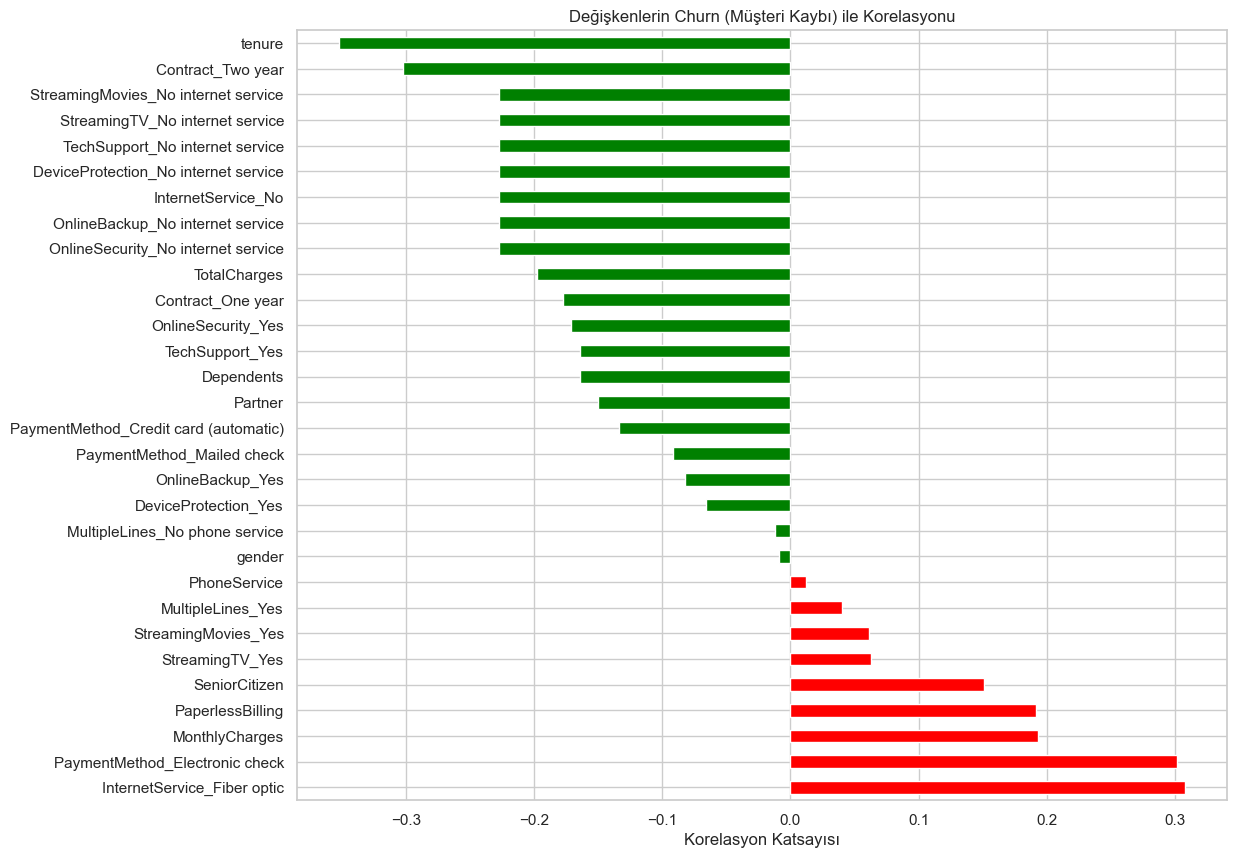

In [13]:
# Encoding (Label Encoding - Binary)
le = LabelEncoder()
binary_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() == 2]
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Encoding (One-Hot Encoding - Multi-class)
df = pd.get_dummies(df, drop_first=True)

# Scaling (İsteğe bağlı ama model için gerekli, korelasyonu etkilemez ama hazır olsun)
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# 2. KORELASYON ANALİZİ
# Hedef değişkenimiz 'Churn' ile diğer tüm değişkenlerin ilişkisi
correlation = df.corr()['Churn'].sort_values(ascending=False)

# İlk 5 (En çok kaybettirenler) ve Son 5 (En çok tutanlar)
print("--- CHURN İLE EN YÜKSEK POZİTİF İLİŞKİSİ OLANLAR (Müşteri Kaybettirenler) ---")
print(correlation.head(6)) # İlk sırada Churn'ün kendisi olacağı için 6 aldık

print("\n--- CHURN İLE EN YÜKSEK NEGATİF İLİŞKİSİ OLANLAR (Müşteri Tutanlar) ---")
print(correlation.tail(5))

# 3. GÖRSELLEŞTİRME (Bar Plot)
plt.figure(figsize=(12, 10))
# Churn'ün kendisini grafikten çıkarıyoruz (korelasyonu 1.0 olduğu için)
correlation.drop('Churn').plot(kind='barh', color=correlation.drop('Churn').apply(lambda x: 'red' if x > 0 else 'green'))
plt.title('Değişkenlerin Churn (Müşteri Kaybı) ile Korelasyonu')
plt.xlabel('Korelasyon Katsayısı')
plt.show()

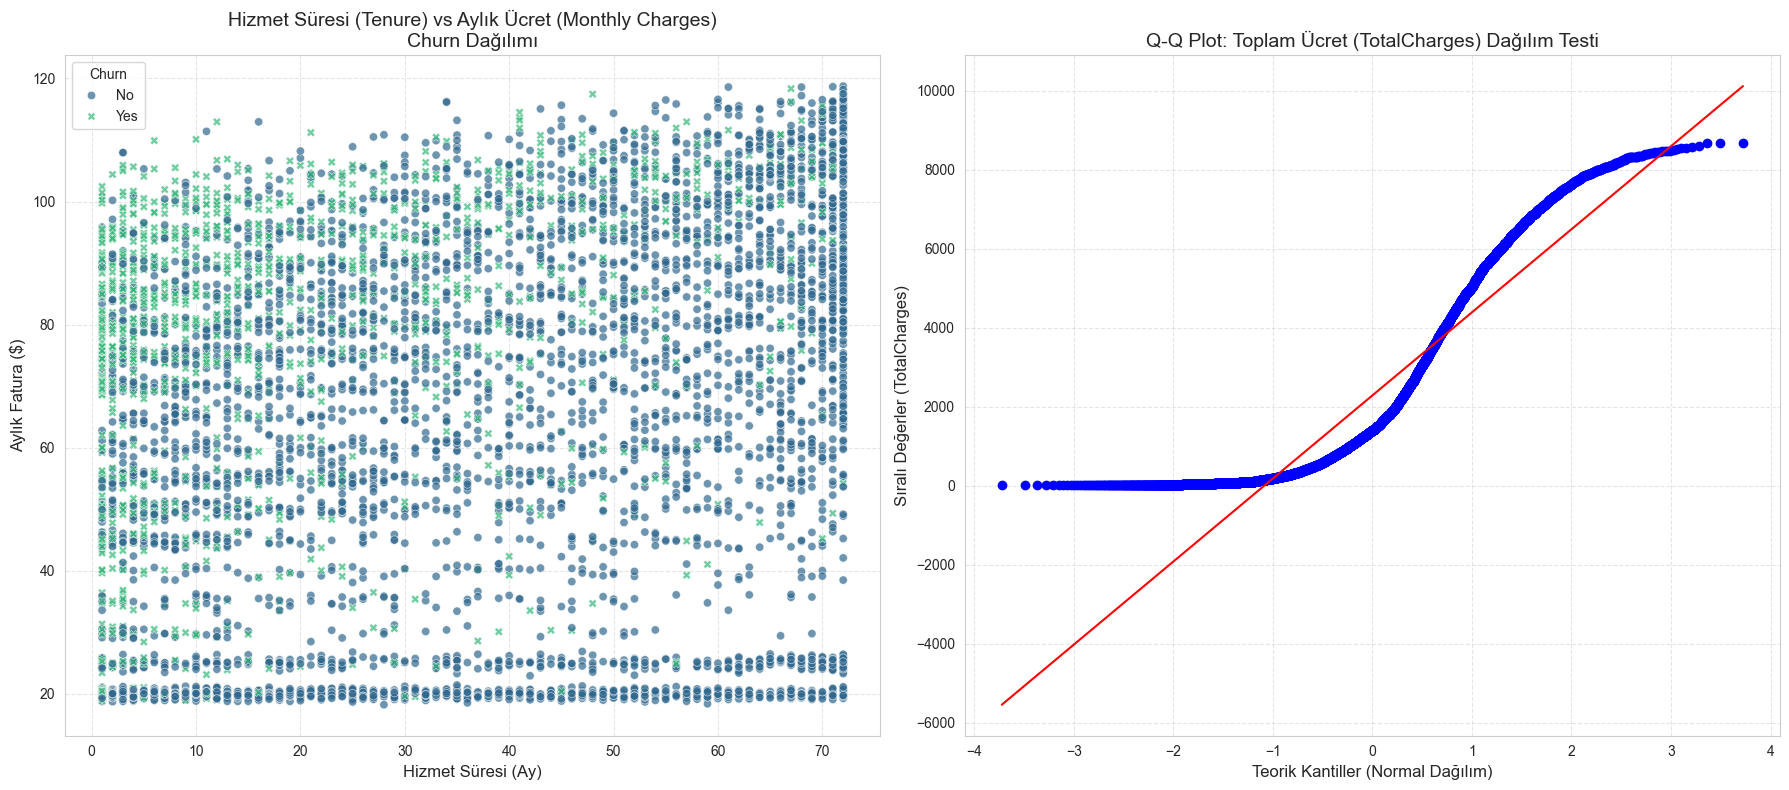

In [5]:
# Veri setini yükleme
df = pd.read_csv('musteri_kayip.csv')

# 'TotalCharges' sütunundaki boşlukları temizleyip sayısal veriye çevirme
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Eksik verileri temizleme

# Grafik ayarları
plt.figure(figsize=(18, 8))

# --- 1. SCATTER PLOT (Saçılım Grafiği) ---
# Amaç: Hizmet süresi ve Fatura tutarı arasındaki ilişkinin Churn üzerindeki etkisini görmek.
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', style='Churn', palette='viridis', alpha=0.7)
plt.title('Hizmet Süresi (Tenure) vs Aylık Ücret (Monthly Charges)\nChurn Dağılımı', fontsize=14)
plt.xlabel('Hizmet Süresi (Ay)', fontsize=12)
plt.ylabel('Aylık Fatura ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# --- 2. QUANTILE PLOT (Q-Q Plot) ---
# Amaç: TotalCharges değişkeninin normal dağılıma uygunluğunu test etmek.
plt.subplot(1, 2, 2)
stats.probplot(df['TotalCharges'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Toplam Ücret (TotalCharges) Dağılım Testi', fontsize=14)
plt.xlabel('Teorik Kantiller (Normal Dağılım)', fontsize=12)
plt.ylabel('Sıralı Değerler (TotalCharges)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [2]:
# 2. TotalCharges sütunundaki boşlukları (string) 0 ile doldurup sayısal tipe çevirme
# (Veri setinde 11 satırda boşluk karakteri mevcuttu)
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 3. Label Encoding (Sadece 2 kategorisi olan değişkenler için)
# Bu işlem Yes/No veya Male/Female gibi ikili değerleri 0 ve 1 yapar.
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 4. One-Hot Encoding (3 veya daha fazla kategorisi olan değişkenler için)
# Bu işlem her kategoriyi yeni bir sütun yapar (Kukla Değişkenler).
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
]

# drop_first=True: İlk kategoriyi atarak 'kukla değişken tuzağını' önler ve modelin daha verimli çalışmasını sağlar.
df_final = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# 5. Model için anlamsız olan customerID sütununu kaldırma
df_final = df_final.drop('customerID', axis=1)

# Sonucu inceleme
print(f"İşlem sonrası veri seti boyutu: {df_final.shape}")
print(df_final.head())

İşlem sonrası veri seti boyutu: (7043, 31)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0                0                                0                

In [4]:
# 1. Özellikleri (X) ve Hedef Değişkeni (y) Ayırma
# 'Churn' bizim tahmin etmek istediğimiz değer, diğerleri girdilerimizdir.
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Train-Test Split (Veriyi Bölme)
# Verinin %80'ini eğitim, %20'sini test için ayırıyoruz. 
# random_state=42, sonuçların her çalıştırdığınızda aynı çıkmasını sağlar.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Feature Scaling (Ölçeklendirme)
# Bazı sütunlar (MonthlyCharges, TotalCharges, tenure) çok yüksek değerlere sahipken,
# encoding yaptığımız sütunlar sadece 0 ve 1'den oluşuyor.
# StandardScaler, sayısal değerleri ortalaması 0, standart sapması 1 olacak şekilde dönüştürür.

scaler = StandardScaler()

# Sadece sayısal (sürekli) sütunları ölçeklendirmek daha sağlıklıdır 
# Ancak tüm X setine uygulamak da modellerin çoğunda sorun yaratmaz.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (5634, 30)
Test seti boyutu: (1409, 30)


In [7]:


# 1. Veriyi Ayırma (X: Özellikler, y: Hedef)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Train-Test Split (Veriyi Bölme)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Feature Scaling (Ölçeklendirme)
# Burada X_train_scaled ve X_test_scaled değişkenlerini tanımlıyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Decision Tree Modelini Tanımlama ve Eğitme
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 5. Tahmin Yapma
y_pred_dt = dt_model.predict(X_test_scaled)

# 6. Sonuçları Görüntüleme
print(f"Decision Tree Doğruluğu: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nKarmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Doğruluğu: 0.7111

Karmaşıklık Matrisi:
[[834 202]
 [205 168]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      1036
           1       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



In [8]:
from sklearn.tree import DecisionTreeClassifier

# class_weight='balanced' eklemek yeterlidir
model_balanced = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
model_balanced.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [9]:
# Tahmin yap
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Sonuçları görüntüle
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1036
           1       0.51      0.79      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409

[[755 281]
 [ 78 295]]
